# Campos eléctricos en dieléctricos
Para la interfaz entre un dieléctrico y el vacío deben cumplirse las condiciones:
$$E_{||,1} = E_{||,2}\quad ; \quad \epsilon_1 E_{\bot,1} = \epsilon_2 E_{\bot,2}$$
El flujo de trabajo para el problema de la clase de hoy sigue los siguientes pasos:
1. Reslver la ecuación de Laplace para el potencial
$$V_{i,j} = \frac{1}{4}(V_{i+1,j}+V_{i-1,j}+V_{i,j+1}+V_{i, j-1})$$
2. Modelar un cilindro dieléctrico en un campo uniforme
$$\vec{E} = E_0 \hat{x}\quad ; \quad V = -E_0 x$$
3. Calcular el campo eléctrico: 
$$\vec{E} = -\nabla V$$
4. Visualizar líneas de campo y equipotenciales
5. Comparar regiones internas y externas al dieléctrico.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
Nx = 200
Ny = 200

x = np.linspace(-1, 1, Nx)
y = np.linspace(-1, 1, Ny)

X, Y = np.meshgrid(x, y)

# Potencial vacío
V = np.zeros((Nx, Ny))

# Valor del campo
E0 = 1.0

for i in range(Nx):
    V[i, :] = -E0 * x


In [3]:
# Radio del cilindro
R = 0.3

# Permtividad relativa
eps_r = 5.0

# Máscara del cilindro 
inside = X ** 2 + Y ** 2 <= R ** 2

In [9]:
iterations = 100
tolerance = 1e-4
for n in range(iterations):

    V_old = V.copy()

    for i in range(1, Ny - 1):
        for j in range(1, Nx - 1):
            
            if inside[i, j]:

                alpha = 1 / eps_r

            else: 

                alpha = 1.0

            V[i, j] = alpha * 0.25 * (
                V_old[i + 1, j] +
                V_old[i - 1, j] +
                V_old[i, j + 1] +
                V_old[i, j - 1]
                )
    # Coondiciones de frontera
    V[:, 0] = E0
    V[:, -1] = - E0
    """
    error = np.max(np.abs(V - V_old))
    if n % 100 == 0:
        print('Iteration: ', n,'Error: ', error)
    if error < tolerance:
        print('Convergencia alcanzada')
        break
    """

# Gradiente numérico
Ey, Ex = np.gradient(-V)

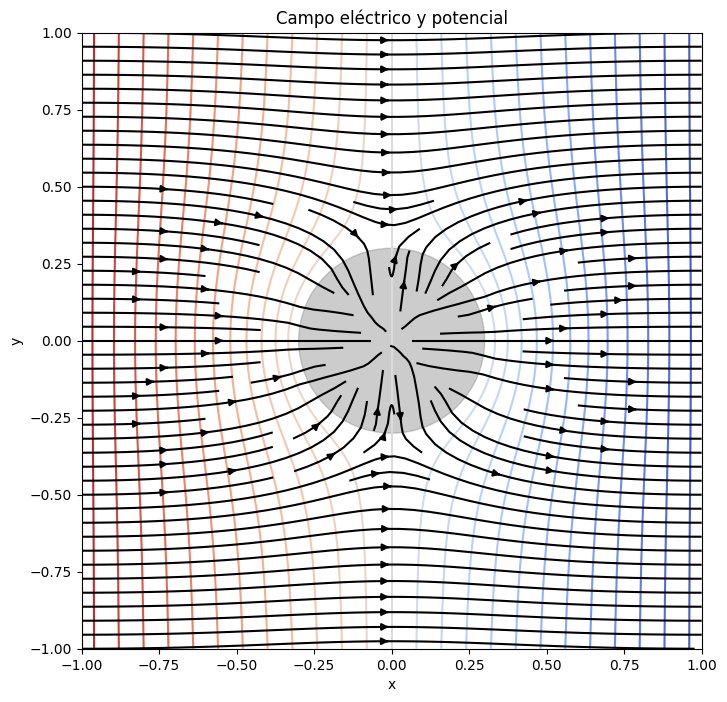

In [27]:
fig, ax = plt.subplots(figsize = (8, 8))

#Equipotenciales
cont = ax.contour(X, Y, V,
                  levels = 30,
                  cmap = 'coolwarm')

# Campo eléctrico

ax.streamplot(X, Y, Ex, Ey,
              color = 'black',
              density = 1.5)

#cilindro
circle = plt.Circle((0, 0),
                    R,
                    color = 'gray',
                    alpha = 0.4)

ax.add_patch(circle)

ax.set_xlabel('x')
ax.set_ylabel('y')

ax.set_title('Campo eléctrico y potencial')
plt.show()

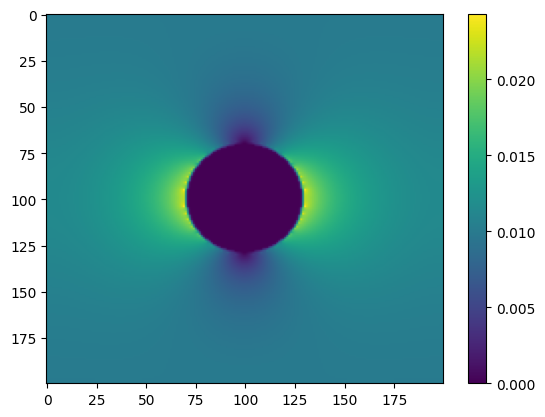

In [26]:
E = np.sqrt(Ex ** 2 + Ey ** 2)
plt.imshow(E, cmap = 'viridis', aspect = 'auto')
plt.colorbar()
plt.show()

# Campos mediante integración
La ley de Gauss nos relaicona la integral de superficie del campo eléctrico con la carga encerrada por dicha superficie. A veces estas integrales pueden escribirse en términos de la integral elíptica completa de priemra serie:
$$K = \int_0^{\pi /2}{\frac{d\theta}{\sqrt{1 -m sin^2\theta}}},\quad 0\leq m\leq$$
Ex posible calcularla numéricamente comparando con la aproximación polinomial:
$$K \sim a_0 + a_1 m +a_2 m^2 - (b_0 +b_1 m + b_2 m^2)ln m + \epsilon(m)$$
# Ejercicio 1
Un plano conductor infinito, delgado y conectado a tierra, con un agujero circular de radio a en su centro. El agujero contiene un disco conductor de radio ligeramente menor, mantenido a un potencial V, y separado del plano por un anillo aislante delgado.
El potencial sobre el eje perpendicular al disco puede expresrse mediante una integral elíptica:
$$\Phi(z) =\frac{V}{2}\left( 1 - \frac{kz}{\pi a} \int_0^{\pi /2}{\frac{d\phi}{\sqrt{1 -m sin^2\phi}}} \right)$$
$$k = \frac{2a}{\sqrt{z^2 + 4a^2}}$$
1. Calcular K(m) evaluando numéricamente la integral 
2. Calcular y graficar el potencial para:


In [30]:
def elliptic_K(m, N = 10000):

    theta = np.linspace(
        0,
        np.pi / 2, 
        N
    )
    integrand = 1.0 / np.sqrt(1 - m * np.sin(theta) ** 2)

    K = np.trapezoid(integrand, theta)
    
    return K

def K_approx(m):
    m1 = 1 - m
    a0 = 1.38622944
    a1 = 0.1119723
    a2 = 0.0725296
    b0 = 0.5
    b1 = 0.1213478
    b2 = 0.0288729

    return (a0 + a1 * m1 + a2 * m1 ** 2) - (b0 + b1 * m1 + b2 * m1 **2) * np.log(m1)

# valores de m
m_vals = np.linspace(0.001, 0.999, 200)

K_num = []
K_poly = []

for m in m_vals:
    K_num.append(elliptic_K(m))
    K_poly.append(K_approx(m))

K_num = np.array(K_num)
K_poly = np.array(K_poly)

#Error absoluto
error = np.abs(K_num - K_poly)
print("Error máximo =", np.max(error))

Error máximo = 9.475233961864227e-05


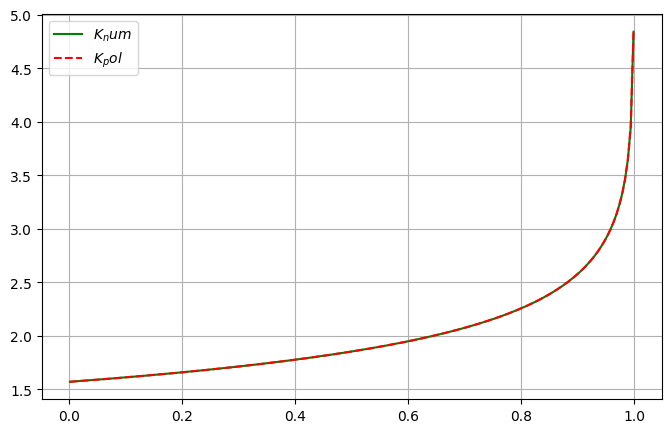

In [46]:
plt.figure(figsize = (8,5))
plt.plot(m_vals, K_num, label = r'$K_num$', color = 'green')
plt.plot(m_vals, K_poly, '--',color = 'red', label = r'$K_pol$')
plt.grid()
plt.legend()
plt.show()

In [41]:
#Potencial Phi
def Phi(z, V = 1, a = 1):

    k = 2 * a / np.sqrt(z ** 2 + 4 * a ** 2)
    K = elliptic_K(k ** 2)
    return ( V / 2 * (1 - (k * z) / np.pi * a) * K)

#valores de z
z_vals = np.linspace(0.05, 10, 300)

phi_vals = []

for z in z_vals:
    phi_vals.append(Phi(z))

phi_vals = np.array(phi_vals)

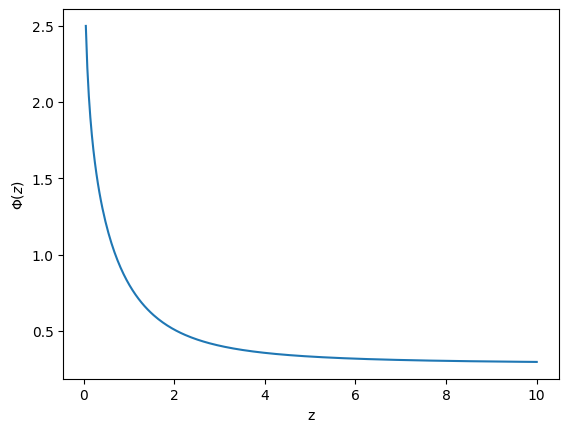

In [45]:
plt.plot(z_vals, phi_vals)
plt.xlabel('z')
plt.ylabel(r'$\Phi(z)$')
plt.show()

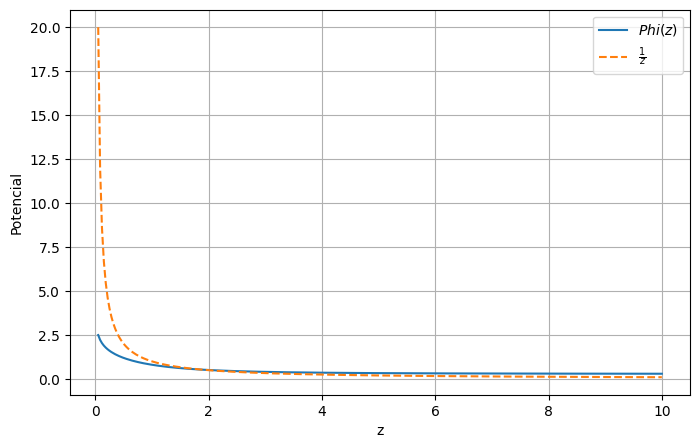

In [49]:
# comparación con 1/r
plt.figure(figsize = (8,5))
plt.plot(z_vals, phi_vals, label = r'$Phi (z)$')
plt.plot(z_vals, 1/z_vals, '--', label = r'$\frac{1}{z}$')
plt.xlabel('z')
plt.ylabel('Potencial')
plt.legend()
plt.grid()
plt.show()